In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
buy=pd.read_excel("./Full_DataFrame_Real_Estate_2.xlsx")

In [4]:
buy

,Name,Builder,Type of Appartment(BHK),Price,Area,City,Status,Date of Construction
0,Bricks Marvella,Bricks Ramabhupal Projects LLP,3,₹1.33 - 1.83 Cr,Tellapur,Hyderabad,Under Construction,"Dec, 2027"
1,Bricks Marvella,Bricks Ramabhupal Projects LLP,4,₹2.64 Cr,Tellapur,Hyderabad,Under Construction,"Dec, 2027"
2,URBANYARDS SHANGRILA,TempleTree Developers LLP,2,₹87.96 L,Tukkuguda,Hyderabad,New Launch,"Jun, 2028"
3,URBANYARDS SHANGRILA,TempleTree Developers LLP,3,₹1.06 - 1.74 Cr,Tukkuguda,Hyderabad,New Launch,"Jun, 2028"
4,GHR Trivana,GHR INFRA,4,₹3.66 Cr,Tukkuguda,Hyderabad,New Launch,"Feb, 2030"
...,...,...,...,...,...,...,...,...
1228,Dwaarika Heights,Prasandi Group,4,₹1.15 - 1.29 Cr,Ved Vyas Puri,Meerut,Ready To Move,"Mar, 2020"
1229,Ashapurna NRI,Ashapurna Buildcon,2,₹38 L,Pali Road,Jodhpur,Ready To Move,"Oct, 2024"
1230,Ashapurna NRI,Ashapurna Buildcon,3,₹81 L,Pali Road,Jodhpur,Ready To Move,"Oct, 2024"
1231,Ashiana Dwarka,Ashiana Housing,2,₹50.29 L,Pal-Sangriya Link Road,Jodhpur,Under Construction,"Jul, 2026"


## Real_Estate_Buy_Data_Analysis

### Understanding the data

In [7]:
buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Name                     1233 non-null   object
 1   Builder                  1231 non-null   object
 2   Type of Appartment(BHK)  1233 non-null   int64 
 3   Price                    1233 non-null   object
 4   Area                     1221 non-null   object
 5   City                     1233 non-null   object
 6   Status                   1233 non-null   object
 7   Date of Construction     1230 non-null   object
dtypes: int64(1), object(7)
memory usage: 77.2+ KB


In [8]:
buy.shape

(1233, 8)

In [9]:
buy.size

9864

In [10]:
buy.columns

Index(['Name', 'Builder', 'Type of Appartment(BHK)', 'Price', 'Area', 'City',
       'Status', 'Date of Construction'],
      dtype='object')

### Info about DataFrame
- As we can see we have 8 1233 rows and 8 columns
- where 7 are in object datatype and one is integer
- 3 of our columns have null values

### Data Cleaning

lets see how much percentage of data is missing

In [11]:
(buy.isna().sum()/len(buy))*100

Name                       0.000000
Builder                    0.162206
Type of Appartment(BHK)    0.000000
Price                      0.000000
Area                       0.973236
City                       0.000000
Status                     0.000000
Date of Construction       0.243309
dtype: float64

As we can see we have less then 1% data as missing values lets remove them

In [12]:
buy.dropna(inplace=True)

In [13]:
buy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1216 entries, 0 to 1232
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Name                     1216 non-null   object
 1   Builder                  1216 non-null   object
 2   Type of Appartment(BHK)  1216 non-null   int64 
 3   Price                    1216 non-null   object
 4   Area                     1216 non-null   object
 5   City                     1216 non-null   object
 6   Status                   1216 non-null   object
 7   Date of Construction     1216 non-null   object
dtypes: int64(1), object(7)
memory usage: 85.5+ KB


- Null values are removed lets remove duplicate rows

In [14]:
buy.duplicated().sum()

np.int64(79)

In [15]:
buy.drop_duplicates(inplace=True)

In [16]:
buy.duplicated().sum()

np.int64(0)

- we had 79 duplicate rows which have been removed

In [17]:
buy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1137 entries, 0 to 1232
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Name                     1137 non-null   object
 1   Builder                  1137 non-null   object
 2   Type of Appartment(BHK)  1137 non-null   int64 
 3   Price                    1137 non-null   object
 4   Area                     1137 non-null   object
 5   City                     1137 non-null   object
 6   Status                   1137 non-null   object
 7   Date of Construction     1137 non-null   object
dtypes: int64(1), object(7)
memory usage: 79.9+ KB


### Lets Check Each column seperately

In [18]:
buy["Name"].unique()

array(['Bricks Marvella', 'URBANYARDS SHANGRILA', 'GHR Trivana',
       'Candeur Crescent', 'NSL East Luxoria', 'ASBL Landmark',
       'Asbl Spectra', 'ASBL Loft', 'Radhey Skye', 'ASBL Broadway',
       'Pranathis Kiara', 'Primark Eco Nest', 'Sattva Lake Ridge',
       'Aparna Moonstone', 'Fiora By Yashoda', 'Casagrand Evon',
       'Savya The Edition', 'Lansum Elena', 'EIPL The Tamarind',
       'Ambience Beaumonde', 'Tridasa Rise', 'Hallmark Treasor',
       'MiliArium By Eeshanya', 'Aparna Newlands', 'Vishal Sanjivini',
       'Sumadhura Solace', 'Sumadhura Edition', 'Vaishno Serene',
       'Keya The Lake Terraces', 'Pride Euphora', 'Trendsquares Akino',
       'Sumadhura Capitol Residences', 'Suyug The ', 'Suyug Saffron',
       'Mahaveer Celesse', 'Mahaveer Highlands', 'Mythri Sity',
       'CasaLife by Bhavisha Homes', 'Vaishnavi AT One Krishna Brindavan',
       'Casagrand Promenade', 'Ira By The Banks', 'Casagrand Estancia',
       'Reviva By SSI', 'Mahaveer Northscape', 'Key

In [19]:
buy["Name"].value_counts()

Name
Ganguly                  5
Casagrand Flagship       4
Aparajita Sports City    4
Piya Elite               4
Casagrand Holachennai    4
                        ..
ASBL Broadway            1
ASBL Loft                1
Asbl Spectra             1
Candeur Crescent         1
GHR Trivana              1
Name: count, Length: 571, dtype: int64

As we can see Names Column is clean there is no need of any changes

In [20]:
buy["Builder"].unique()

array(['Bricks Ramabhupal Projects LLP', 'TempleTree Developers LLP',
       'GHR INFRA', 'Candeur Constructions', 'NSL Infratech', 'ASBL',
       'Radhey Constructions', 'Pranathi Constructions',
       'Primark Projects', 'Sattva Group', 'Aparna Constructions',
       'Yashoda Infra Developers', 'Casagrand', 'Savya Realty LLP',
       'Lansum Enpoint Developers', 'EIPL Group', 'Koncept Ambience',
       'Tridasa Realty Ventures', 'Hallmark ', 'Eeshanya Infra',
       'Vishal Projects', 'Sumadhura Group', 'Vaishno ', 'Keya Homes',
       'Pride Group', 'Trendsquares Constructions', 'Suyug Infra',
       'Mahaveer Group', 'Mythri ', 'Bhavisha Properties',
       'Vaishnavi Group Bangalore', 'Alcove Properties',
       'Sri Sai Infra Bangalore', 'Amberstone Properties',
       'Ma Sarada Constructions Bangalore', 'Navanaami Projects',
       'Amrutha Shelters', 'CasagrandView Number',
       'Navin Housing and Properties', 'Jain Housing', "Navin's",
       'BSCPL Infrastructure', 'Radia

Here as we can see due to unavailability of builder name some data is misplaced lets correct it

In [21]:
c=0
for i in buy["Builder"]:
    if "Floor" in i:
        c+=1
        buy["Builder"]=buy["Builder"].replace(i,"NA")
print(c)     

79


In [22]:
buy["Builder"].unique()

array(['Bricks Ramabhupal Projects LLP', 'TempleTree Developers LLP',
       'GHR INFRA', 'Candeur Constructions', 'NSL Infratech', 'ASBL',
       'Radhey Constructions', 'Pranathi Constructions',
       'Primark Projects', 'Sattva Group', 'Aparna Constructions',
       'Yashoda Infra Developers', 'Casagrand', 'Savya Realty LLP',
       'Lansum Enpoint Developers', 'EIPL Group', 'Koncept Ambience',
       'Tridasa Realty Ventures', 'Hallmark ', 'Eeshanya Infra',
       'Vishal Projects', 'Sumadhura Group', 'Vaishno ', 'Keya Homes',
       'Pride Group', 'Trendsquares Constructions', 'Suyug Infra',
       'Mahaveer Group', 'Mythri ', 'Bhavisha Properties',
       'Vaishnavi Group Bangalore', 'Alcove Properties',
       'Sri Sai Infra Bangalore', 'Amberstone Properties',
       'Ma Sarada Constructions Bangalore', 'Navanaami Projects',
       'Amrutha Shelters', 'CasagrandView Number',
       'Navin Housing and Properties', 'Jain Housing', "Navin's",
       'BSCPL Infrastructure', 'Radia

Now Builder column is cleaned

In [23]:
buy["Type of Appartment(BHK)"].unique()

array([3, 4, 2, 1])

As we can this column is already cleaned no need to change anything

In [24]:
buy["Price"].unique()

array(['₹1.33 - 1.83 Cr', '₹2.64 Cr', '₹87.96 L', '₹1.06 - 1.74 Cr',
       '₹3.66 Cr', '₹1.5 - 2.49 Cr', '₹1.34 - 1.89 Cr', '₹2.31 - 2.41 Cr',
       '₹2.6 - 2.72 Cr', '₹3.04 Cr', '₹2.25 - 2.52 Cr', '₹1.94 - 2.14 Cr',
       '₹92.74 - 94.49 L', '₹1.2 - 1.83 Cr', '₹2.17 - 2.83 Cr',
       '₹1.4 - 1.49 Cr', '₹63.78 - 71.76 L', '₹78.36 L - 1.19 Cr',
       '₹3.6 - 4.49 Cr', '₹2.5 - 3.19 Cr', '₹3.4 - 3.62 Cr',
       '₹4.48 - 5.36 Cr', '₹1.64 Cr', '₹2.25 Cr', '₹4.44 Cr', '₹2.9 Cr',
       '₹3.59 - 4.15 Cr', '₹1.88 Cr', '₹1.77 - 2.23 Cr',
       '₹1.42 - 1.73 Cr', '₹2.27 Cr', '₹1.78 - 5.33 Cr',
       '₹3.71 - 4.28 Cr', '₹1.07 - 1.66 Cr', '₹1.66 - 1.97 Cr',
       '₹1.5 - 2.01 Cr', '₹3.6 - 5.26 Cr', '₹2.47 - 3.25 Cr',
       '₹2.76 - 4.19 Cr', '₹1.7 - 1.81 Cr', '₹1.98 - 2.55 Cr',
       '₹2.6 - 3.05 Cr', '₹1.13 - 1.36 Cr', '₹1.22 - 1.29 Cr',
       '₹1.67 - 1.7 Cr', '₹2.4 Cr', '₹1.99 - 2.26 Cr', '₹3.4 - 3.55 Cr',
       '₹1.6 - 1.77 Cr', '₹2.04 - 2.07 Cr', '₹2.49 - 3.27 Cr', '₹3.21 Cr',
  

This column should be integer/float but we have string lets convert it to float and the lets convert all values to lakhs and find average if we have range

In [25]:
buy["Price"] = buy["Price"].str.replace("₹","")

In [26]:
buy["Price"] = buy["Price"].str.replace("Cr","").str.replace("L","")

In [27]:
buy["Price"].unique()

array(['1.33 - 1.83 ', '2.64 ', '87.96 ', '1.06 - 1.74 ', '3.66 ',
       '1.5 - 2.49 ', '1.34 - 1.89 ', '2.31 - 2.41 ', '2.6 - 2.72 ',
       '3.04 ', '2.25 - 2.52 ', '1.94 - 2.14 ', '92.74 - 94.49 ',
       '1.2 - 1.83 ', '2.17 - 2.83 ', '1.4 - 1.49 ', '63.78 - 71.76 ',
       '78.36  - 1.19 ', '3.6 - 4.49 ', '2.5 - 3.19 ', '3.4 - 3.62 ',
       '4.48 - 5.36 ', '1.64 ', '2.25 ', '4.44 ', '2.9 ', '3.59 - 4.15 ',
       '1.88 ', '1.77 - 2.23 ', '1.42 - 1.73 ', '2.27 ', '1.78 - 5.33 ',
       '3.71 - 4.28 ', '1.07 - 1.66 ', '1.66 - 1.97 ', '1.5 - 2.01 ',
       '3.6 - 5.26 ', '2.47 - 3.25 ', '2.76 - 4.19 ', '1.7 - 1.81 ',
       '1.98 - 2.55 ', '2.6 - 3.05 ', '1.13 - 1.36 ', '1.22 - 1.29 ',
       '1.67 - 1.7 ', '2.4 ', '1.99 - 2.26 ', '3.4 - 3.55 ',
       '1.6 - 1.77 ', '2.04 - 2.07 ', '2.49 - 3.27 ', '3.21 ',
       '1.47 - 1.78 ', '1.5 - 1.65 ', '2.01 - 2.06 ', '1.01 - 1.31 ',
       '1.48 - 1.72 ', 'Price on Request', '87.85  - 1.1 ', '1.28 - 1.3 ',
       '1.07 - 1.16 ', '1.13 - 1

In [28]:
pric=[]
for i in buy["Price"]:
    if "-" in i:
        pric.append(i.split("-"))
    else:
        pric.append(i)

In [29]:
price=[]

for i in pric:
    if type(i)==list:
        for j in range(len(i)):
            i[j]=float(i[j].strip())
        price.append(i)
    elif "Price on Request" in i:
        price.append(np.nan)
    elif type(i)!=list and type(i)!=float and i.isalpha()!=True:
        price.append(float(i.strip()))
    else:
        price.append(np.nan)
        
        

In [30]:
converted = []
for i in price:
    if isinstance(i, list):
        temp = []
        for j in i:
            if j < 10:
                temp.append(round(j*100,2))
            else:
                temp.append(round(j,2))
        converted.append(temp)
    elif isinstance(i,(int,float)):
        if np.isnan(i):
            converted.append(np.nan)
        elif i < 10:
            converted.append(round(i*100,2))
        else:
            converted.append(round(i,2))

In [31]:
converted

[[133.0, 183.0],
 264.0,
 87.96,
 [106.0, 174.0],
 366.0,
 [150.0, 249.0],
 [134.0, 189.0],
 [231.0, 241.0],
 [260.0, 272.0],
 304.0,
 [225.0, 252.0],
 [194.0, 214.0],
 [92.74, 94.49],
 [120.0, 183.0],
 [217.0, 283.0],
 [140.0, 149.0],
 [63.78, 71.76],
 [78.36, 119.0],
 [360.0, 449.0],
 [250.0, 319.0],
 [340.0, 362.0],
 [448.0, 536.0],
 164.0,
 225.0,
 444.0,
 290.0,
 [359.0, 415.0],
 188.0,
 [177.0, 223.0],
 [142.0, 173.0],
 227.0,
 [178.0, 533.0],
 [371.0, 428.0],
 [107.0, 166.0],
 [166.0, 197.0],
 [150.0, 201.0],
 [360.0, 526.0],
 [247.0, 325.0],
 [276.0, 419.0],
 [170.0, 181.0],
 [198.0, 255.0],
 [260.0, 305.0],
 [113.0, 136.0],
 [122.0, 129.0],
 [167.0, 170.0],
 240.0,
 [199.0, 226.0],
 [340.0, 355.0],
 [160.0, 177.0],
 [204.0, 207.0],
 [249.0, 327.0],
 321.0,
 [147.0, 178.0],
 [150.0, 165.0],
 [201.0, 206.0],
 [101.0, 131.0],
 [148.0, 172.0],
 nan,
 [87.85, 110.0],
 [128.0, 130.0],
 [107.0, 116.0],
 [113.0, 187.0],
 230.0,
 [195.0, 308.0],
 [247.0, 359.0],
 [350.0, 354.0],
 443.0

In [32]:
buy["Price"]=converted

In [33]:
buy

,Name,Builder,Type of Appartment(BHK),Price,Area,City,Status,Date of Construction
0,Bricks Marvella,Bricks Ramabhupal Projects LLP,3,"[133.0, 183.0]",Tellapur,Hyderabad,Under Construction,"Dec, 2027"
1,Bricks Marvella,Bricks Ramabhupal Projects LLP,4,264.0,Tellapur,Hyderabad,Under Construction,"Dec, 2027"
2,URBANYARDS SHANGRILA,TempleTree Developers LLP,2,87.96,Tukkuguda,Hyderabad,New Launch,"Jun, 2028"
3,URBANYARDS SHANGRILA,TempleTree Developers LLP,3,"[106.0, 174.0]",Tukkuguda,Hyderabad,New Launch,"Jun, 2028"
4,GHR Trivana,GHR INFRA,4,366.0,Tukkuguda,Hyderabad,New Launch,"Feb, 2030"
...,...,...,...,...,...,...,...,...
1228,Dwaarika Heights,Prasandi Group,4,"[115.0, 129.0]",Ved Vyas Puri,Meerut,Ready To Move,"Mar, 2020"
1229,Ashapurna NRI,Ashapurna Buildcon,2,38.0,Pali Road,Jodhpur,Ready To Move,"Oct, 2024"
1230,Ashapurna NRI,Ashapurna Buildcon,3,81.0,Pali Road,Jodhpur,Ready To Move,"Oct, 2024"
1231,Ashiana Dwarka,Ashiana Housing,2,50.29,Pal-Sangriya Link Road,Jodhpur,Under Construction,"Jul, 2026"


In [34]:
avg=[]
for i in buy["Price"]:
    if type(i)==list:
        for j in range(len(i)):
            a=i[0]
            b=i[1]
        avg.append(round((a+b)/2,2))
    else:
        avg.append(i)
    

In [35]:
len(avg)

1137

In [36]:
buy["Average Price"]=avg

In [37]:
buy

,Name,Builder,Type of Appartment(BHK),Price,Area,City,Status,Date of Construction,Average Price
0,Bricks Marvella,Bricks Ramabhupal Projects LLP,3,"[133.0, 183.0]",Tellapur,Hyderabad,Under Construction,"Dec, 2027",158.00
1,Bricks Marvella,Bricks Ramabhupal Projects LLP,4,264.0,Tellapur,Hyderabad,Under Construction,"Dec, 2027",264.00
2,URBANYARDS SHANGRILA,TempleTree Developers LLP,2,87.96,Tukkuguda,Hyderabad,New Launch,"Jun, 2028",87.96
3,URBANYARDS SHANGRILA,TempleTree Developers LLP,3,"[106.0, 174.0]",Tukkuguda,Hyderabad,New Launch,"Jun, 2028",140.00
4,GHR Trivana,GHR INFRA,4,366.0,Tukkuguda,Hyderabad,New Launch,"Feb, 2030",366.00
...,...,...,...,...,...,...,...,...,...
1228,Dwaarika Heights,Prasandi Group,4,"[115.0, 129.0]",Ved Vyas Puri,Meerut,Ready To Move,"Mar, 2020",122.00
1229,Ashapurna NRI,Ashapurna Buildcon,2,38.0,Pali Road,Jodhpur,Ready To Move,"Oct, 2024",38.00
1230,Ashapurna NRI,Ashapurna Buildcon,3,81.0,Pali Road,Jodhpur,Ready To Move,"Oct, 2024",81.00
1231,Ashiana Dwarka,Ashiana Housing,2,50.29,Pal-Sangriya Link Road,Jodhpur,Under Construction,"Jul, 2026",50.29


In [38]:
(buy.loc[buy["City"]=="Hyderabad","Average Price"]).mean(skipna=True)

np.float64(241.55459459459462)

In [39]:
buy.loc[(buy["Price"].isna()) & (buy["City"]=="Bangalore"),"Average Price"]

57   NaN
Name: Average Price, dtype: float64

In [41]:
buy

,Name,Builder,Type of Appartment(BHK),Price,Area,City,Status,Date of Construction,Average Price
0,Bricks Marvella,Bricks Ramabhupal Projects LLP,3,"[133.0, 183.0]",Tellapur,Hyderabad,Under Construction,"Dec, 2027",158.00
1,Bricks Marvella,Bricks Ramabhupal Projects LLP,4,264.0,Tellapur,Hyderabad,Under Construction,"Dec, 2027",264.00
2,URBANYARDS SHANGRILA,TempleTree Developers LLP,2,87.96,Tukkuguda,Hyderabad,New Launch,"Jun, 2028",87.96
3,URBANYARDS SHANGRILA,TempleTree Developers LLP,3,"[106.0, 174.0]",Tukkuguda,Hyderabad,New Launch,"Jun, 2028",140.00
4,GHR Trivana,GHR INFRA,4,366.0,Tukkuguda,Hyderabad,New Launch,"Feb, 2030",366.00
...,...,...,...,...,...,...,...,...,...
1228,Dwaarika Heights,Prasandi Group,4,"[115.0, 129.0]",Ved Vyas Puri,Meerut,Ready To Move,"Mar, 2020",122.00
1229,Ashapurna NRI,Ashapurna Buildcon,2,38.0,Pali Road,Jodhpur,Ready To Move,"Oct, 2024",38.00
1230,Ashapurna NRI,Ashapurna Buildcon,3,81.0,Pali Road,Jodhpur,Ready To Move,"Oct, 2024",81.00
1231,Ashiana Dwarka,Ashiana Housing,2,50.29,Pal-Sangriya Link Road,Jodhpur,Under Construction,"Jul, 2026",50.29


In [42]:
buy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1137 entries, 0 to 1232
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Name                     1137 non-null   object 
 1   Builder                  1137 non-null   object 
 2   Type of Appartment(BHK)  1137 non-null   int64  
 3   Price                    1057 non-null   object 
 4   Area                     1137 non-null   object 
 5   City                     1137 non-null   object 
 6   Status                   1137 non-null   object 
 7   Date of Construction     1137 non-null   object 
 8   Average Price            1057 non-null   float64
dtypes: float64(1), int64(1), object(7)
memory usage: 88.8+ KB


In [43]:
a = buy["City"].unique().tolist()

In [44]:
a

['Hyderabad',
 'Bangalore',
 'Whitefield',
 'Chennai',
 'Coimbatore',
 'Visakhapatnam',
 'Delhi',
 'Mumbai',
 'West',
 'East',
 'Ahmedabad',
 'North',
 'Highway',
 'Road',
 'Kochi',
 'Patna',
 'Varanasi',
 'Palakkad',
 'Trivandrum',
 'Calicut',
 'Thrissur',
 'Ranchi',
 'Guwahati',
 'Kolkata',
 'Shibpur',
 'Bypass',
 'Howrah',
 'South',
 'Madhyamgram',
 'Pune',
 'Charholi',
 'Jaipur',
 'Lucknow',
 'Nagpur',
 'Allahabad',
 'Amritsar',
 'Dhanbad',
 'Chandigarh',
 'Thane',
 'Salem',
 'Faridabad',
 'Jalandhar',
 'Vadodara',
 'Vijayawada',
 'Guntur',
 'Nashik',
 'Madurai',
 'Meerut',
 'Jodhpur']

In [45]:
for i in a:
    for i in a:
        buy.loc[(buy["Average Price"].isna()) & (buy["City"] == i), "Average Price"] = buy.loc[buy["City"] == i, "Average Price"].mean()

In [46]:
buy[buy["Average Price"].isna()]["City"]

945    Amritsar
946    Amritsar
947     Dhanbad
948     Dhanbad
Name: City, dtype: object

In [47]:
buy["Average Price"].fillna(buy["Average Price"].mean(), inplace=True)

In [48]:
buy["Price"].isna().sum()

np.int64(80)

In [49]:
buy.loc[buy["Price"].isna(), "Price"] = buy["Average Price"]

In [50]:
buy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1137 entries, 0 to 1232
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Name                     1137 non-null   object 
 1   Builder                  1137 non-null   object 
 2   Type of Appartment(BHK)  1137 non-null   int64  
 3   Price                    1137 non-null   object 
 4   Area                     1137 non-null   object 
 5   City                     1137 non-null   object 
 6   Status                   1137 non-null   object 
 7   Date of Construction     1137 non-null   object 
 8   Average Price            1137 non-null   float64
dtypes: float64(1), int64(1), object(7)
memory usage: 121.1+ KB


Now my price and average price columns are clean

In [51]:
buy["Area"].unique()

array(['Tellapur', 'Tukkuguda', 'Gachibowli', 'Uppal', 'Kukatpally',
       'Narsingi', 'Kollur', 'Financial District', 'Kompally', 'Kokapet',
       'Gopanpally', 'Hi Tech City', 'Manikonda', 'Nallagandla',
       'Marathahalli', 'Nallurhalli', 'Hoodi', 'Electronics City Phase 1',
       'KR Puram', 'Whitefield', 'Sarjapur Road', 'Yelahanka', 'Kengeri',
       'Banashankari Stage 2', 'Electronic City', 'Kogilu', 'Chandapura',
       'Devanahalli', 'Bannerghatta Road', 'Hoskote', 'Kodathi',
       'Rajarajeshwari Nagar', 'Perambur', 'Pammal', 'Manapakkam',
       'Pallikaranai', 'Pallavaram', 'Iyyappanthangal', 'Siruseri',
       'Sholinganallur', 'Kelambakkam', 'Thirumudivakkam', 'Medavakkam',
       'Perungalathur', 'Perungudi', 'OMR', 'Thoraipakkam', 'Kundrathur',
       'Madhavaram', 'Valasaravakkam', 'Goldwins', 'Saravanampatti',
       'Ramanathapuram', 'Ganapathy ', 'Sulur', 'Kavundampalayam',
       'Saibaba Colony ', 'RS Puram ', 'Kannampalayam', 'Thudiyalur ',
       'Kovilpa

Area Column is also clean no need any change

In [52]:
buy["City"].unique()

array(['Hyderabad', 'Bangalore', 'Whitefield', 'Chennai', 'Coimbatore',
       'Visakhapatnam', 'Delhi', 'Mumbai', 'West', 'East', 'Ahmedabad',
       'North', 'Highway', 'Road', 'Kochi', 'Patna', 'Varanasi',
       'Palakkad', 'Trivandrum', 'Calicut', 'Thrissur', 'Ranchi',
       'Guwahati', 'Kolkata', 'Shibpur', 'Bypass', 'Howrah', 'South',
       'Madhyamgram', 'Pune', 'Charholi', 'Jaipur', 'Lucknow', 'Nagpur',
       'Allahabad', 'Amritsar', 'Dhanbad', 'Chandigarh', 'Thane', 'Salem',
       'Faridabad', 'Jalandhar', 'Vadodara', 'Vijayawada', 'Guntur',
       'Nashik', 'Madurai', 'Meerut', 'Jodhpur'], dtype=object)

City Column is also clean no need any change

In [53]:
buy["Status"].unique()

array(['Under Construction', 'New Launch', 'Ready To Move',
       '1 OFFERUnder Construction', '1 OFFERNew Launch',
       'Partially Ready To', 'Ready To MovePadam', 'Ready To MoveSBC',
       'Ready To MoveLovely', 'Ready To MoveMax'], dtype=object)

In this column some unwanted string is added lets remove them

In [54]:
for i in buy["Status"]:
    if "Ready To Move" in i:
        buy["Status"]=buy["Status"].replace(i,"Ready To Move")
    elif "Under Construction" in i:
        buy["Status"]=buy["Status"].replace(i,"Under Construction")
    elif "New Launch" in i:
        buy["Status"]=buy["Status"].replace(i,"New Launch")
    elif "Partially" in i:
        buy["Status"]=buy["Status"].replace(i,"Partially Ready To Move")

In [55]:
buy["Status"].unique()

array(['Under Construction', 'New Launch', 'Ready To Move',
       'Partially Ready To Move'], dtype=object)

Now Status column is also cleaned

Date of Construction

In [56]:
buy["Date of Construction"].unique()

array(['Dec, 2027', 'Jun, 2028', 'Feb, 2030', 'Jun, 2026', 'Mar, 2028',
       'Dec, 2025', 'Dec, 2026', 'Dec, 2029', 'Nov, 2026', 'Aug, 2025',
       'Jan, 2028', 'Jul, 2030', 'Jul, 2028', 'Dec, 2028', 'Feb, 2026',
       'Nov, 2025', 'Aug, 2027', 'Sep, 2027', 'Sep, 2026', 'Mar, 2026',
       'Mar, 2022', 'Nov, 2028', 'Apr, 2026', 'Jun, 2030', 'May, 2024',
       'Apr, 2028', 'Jan, 2031', 'Jun, 2027', 'Mar, 2029', 'Jan, 2029',
       'Apr, 2027', 'Jun, 2029', 'Aug, 2028', 'Oct, 2027', 'Jul, 2029',
       'Oct, 2024', 'Feb, 2029', 'Oct, 2028', 'May, 2026', 'Dec, 2020',
       'Dec, 2030', 'Feb, 2027', 'Nov, 2027', 'Oct, 2025', 'Apr, 2030',
       'Jan, 2026', 'Oct, 2026', 'May, 2025', 'Sep, 2025', 'Apr, 2023',
       'Jul, 2026', 'Aug, 2024', 'Feb, 2024', 'Dec, 2024', 'Jul, 2021',
       'Nov, 2030', 'Aug, 2018', 'Homes3, 4', 'Jul, 2025', 'Nov, 2024',
       'Jul, 2024', 'Floors3, 4', '13, 4', 'Sep, 2024', 'Mar, 2027',
       'Dec, 2031', 'Jun, 2025', 'Dec, 2032', 'Mar, 2031', 'Aug, 20

In [57]:
buy["Date of Construction"] = buy["Date of Construction"].str.extract(r'([A-Za-z]{3},\s*\d{4})')

In [58]:
buy["Date of Construction"] = pd.to_datetime(buy["Date of Construction"], format="%b, %Y", errors="coerce")

In [59]:
buy["Date of Construction"] = buy["Date of Construction"].fillna(buy.groupby("City")["Date of Construction"].transform("median"))

In [60]:
buy["Date of Construction"].unique()

<DatetimeArray>
['2027-12-01 00:00:00', '2028-06-01 00:00:00', '2030-02-01 00:00:00',
 '2026-06-01 00:00:00', '2028-03-01 00:00:00', '2025-12-01 00:00:00',
 '2026-12-01 00:00:00', '2029-12-01 00:00:00', '2026-11-01 00:00:00',
 '2025-08-01 00:00:00',
 ...
 '2016-12-01 00:00:00', '2018-12-01 00:00:00', '2022-11-01 00:00:00',
 '2015-05-01 00:00:00', '2016-03-01 00:00:00', '2011-09-01 00:00:00',
 '2025-04-01 00:00:00', '2031-09-01 00:00:00', '2023-05-01 00:00:00',
 '2020-03-01 00:00:00']
Length: 122, dtype: datetime64[ns]

In [64]:
buy.reset_index(inplace=True)

In [65]:
buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   index                    1137 non-null   int64         
 1   Name                     1137 non-null   object        
 2   Builder                  1137 non-null   object        
 3   Type of Appartment(BHK)  1137 non-null   int64         
 4   Price                    1137 non-null   object        
 5   Area                     1137 non-null   object        
 6   City                     1137 non-null   object        
 7   Status                   1137 non-null   object        
 8   Date of Construction     1137 non-null   datetime64[ns]
 9   Average Price            1137 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 89.0+ KB


In [12]:
buy["Type of Appartment(BHK)"].value_counts()

Type of Appartment(BHK)
3    508
2    302
4    280
1     47
Name: count, dtype: int64

Now My DataFrame is completely cleaned

In [114]:
buy.to_excel("Cleaned_Buy_Real_Estate.xlsx",index=False)

In [3]:
buy=pd.read_excel("././Cleaned_Buy_Real_Estate.xlsx")

### Statistical Analysis

In [5]:
for i in buy:
    print(buy[str(i)].value_counts())

Name
Ganguly                  5
Casagrand Flagship       4
Aparajita Sports City    4
Piya Elite               4
Casagrand Holachennai    4
                        ..
ASBL Broadway            1
ASBL Loft                1
Asbl Spectra             1
Candeur Crescent         1
GHR Trivana              1
Name: count, Length: 571, dtype: int64
Builder
Casagrand                   55
Godrej Properties           25
Kalpataru                   18
Ruparel Realty              10
Ashar                        9
                            ..
Yashoda Infra Developers     1
Sattva Group                 1
Pranathi Constructions       1
Candeur Constructions        1
GHR INFRA                    1
Name: count, Length: 406, dtype: int64
Type of Appartment(BHK)
3    508
2    302
4    280
1     47
Name: count, dtype: int64
Price
127.822083        23
132.694324        16
130                6
85                 6
86.765833          6
                  ..
264                1
87.96              1
[106.0, 174

### Statistical Values of Numeric data


In [6]:
buy.describe()

,Type of Appartment(BHK),Date of Construction,Average Price
count,1137.000000,1137,1137.000000
mean,2.897977,2027-06-17 01:46:23.113456640,164.554921
min,1.000000,2011-09-01 00:00:00,10.840000
25%,2.000000,2026-05-01 00:00:00,81.660000
50%,3.000000,2027-11-01 00:00:00,128.000000
75%,3.000000,2028-12-01 00:00:00,202.500000
max,4.000000,2032-12-01 00:00:00,948.000000
std,0.816945,NaN,127.427021


### Statistical Values of Object data columns


In [7]:
buy.describe(include=object)

,Name,Builder,Price,Area,City,Status
count,1137,1058,1137.000000,1137,1137,1137
unique,571,406,955.000000,358,49,4
top,Ganguly,Casagrand,127.822083,Zirakpur,Chennai,Under Construction
freq,5,55,23.000000,28,64,540


### Data Visualization

### Univariate Analysis


### Top 10 Properties in india`

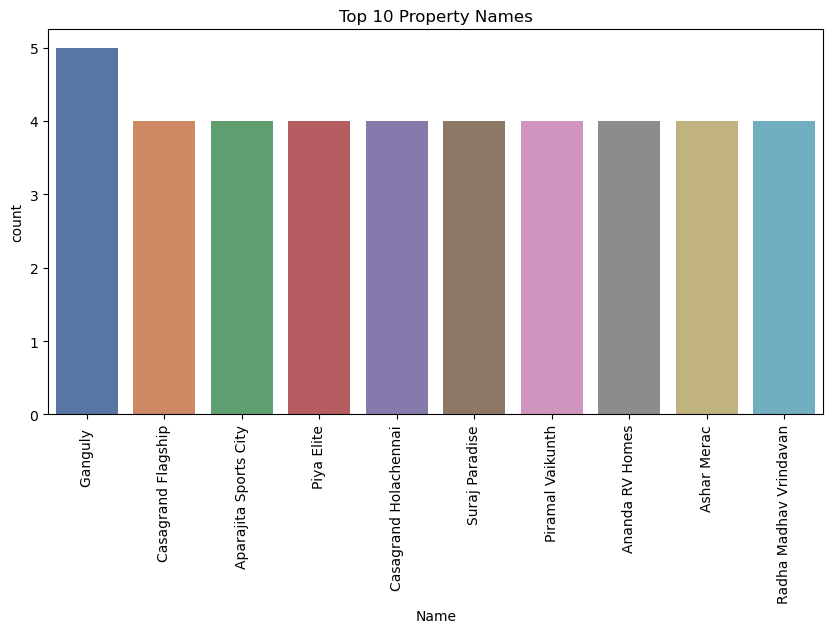

In [18]:
top_names = buy["Name"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(top_names,palette="deep")
plt.xticks(rotation=90)
plt.title("Top 10 Property Names")
plt.show()

- Names of properties which are availbe more in india

### Distribution of BHK

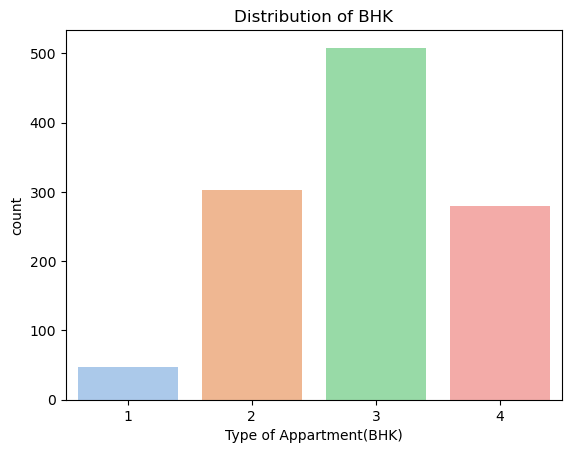

In [36]:
sns.countplot(x="Type of Appartment(BHK)",data=buy,palette='pastel')
plt.title("Distribution of BHK")
plt.show()

- 3 BHK dominates the market with more than 500 listings , making it the most common property type for sale.
- 2 BHK (>300 listings) and 4 BHK (>250 listings) follow, while 1 BHK has only <50 listings, showing smaller homes are less common in this dataset.

### Which are the top 10 cities with the highest number of properties?

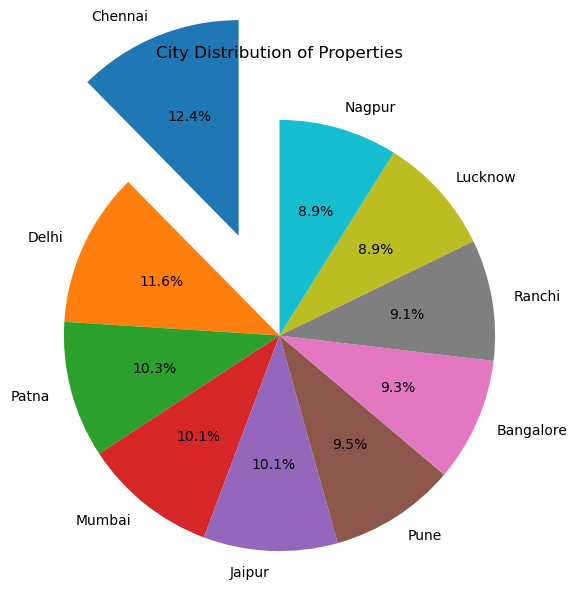

In [5]:
plt.figure(figsize=(7,7))
buy["City"].value_counts().head(10).plot.pie(autopct="%1.1f%%",startangle=90,explode=[0.5,0,0,0,0,0,0,0,0,0])
plt.title("City Distribution of Properties")
plt.ylabel("")
plt.show()

- Chennai (12.4% listings) and Delhi (11.6% listings) have the highest number of properties in the dataset.

In [28]:
buy.columns

Index(['Name', 'Builder', 'Type of Appartment(BHK)', 'Price', 'Area', 'City',
       'Status', 'Date of Construction', 'Average Price'],
      dtype='object')

### Top 10 Builders who got more projects.

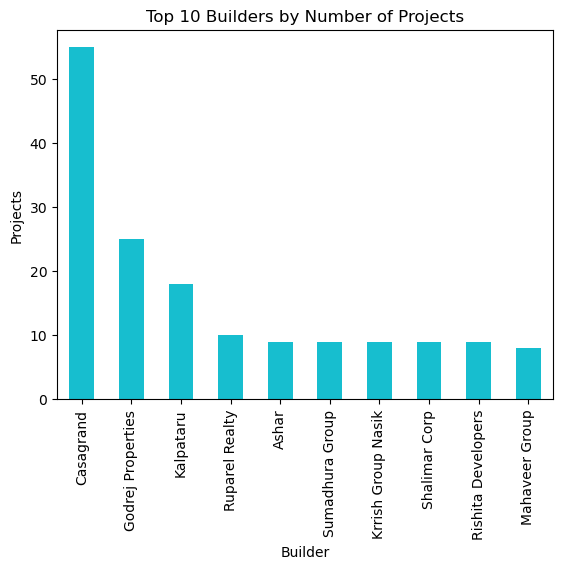

In [6]:
buy["Builder"].value_counts().head(10).plot(kind="bar",color='tab:cyan')
plt.title("Top 10 Builders by Number of Projects")
plt.xlabel("Builder")
plt.ylabel("Projects")
plt.show()

- Casagrand tops the list ofbuilders who got more properties/appartments

### How have construction projects changed over time?

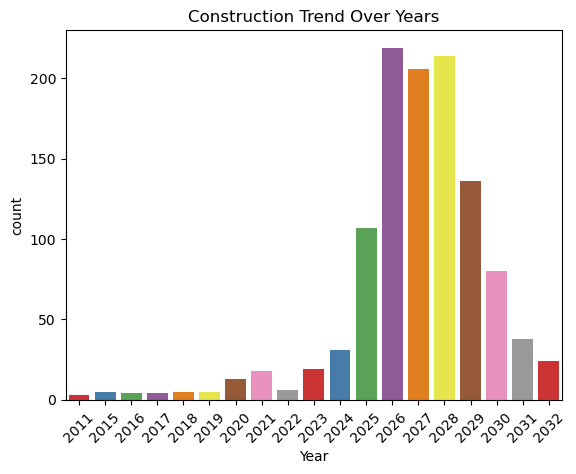

In [7]:
buy["Year"] = buy["Date of Construction"].dt.year
sns.countplot(x="Year",data=buy,palette="Set1")
plt.xticks(rotation=45)
plt.title("Construction Trend Over Years")
plt.show()

- As we can see property construction is boomed b/w 2026 to 2029

### Areas with Highest Property Listings

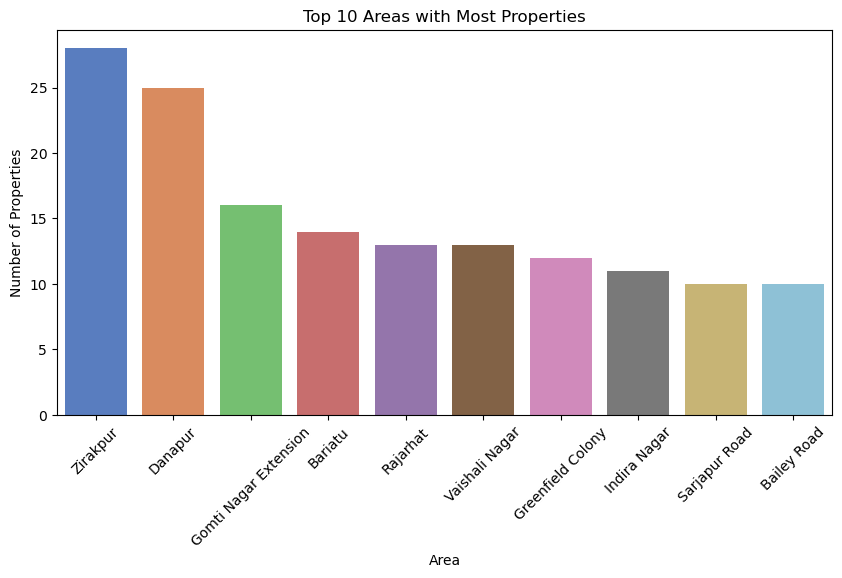

In [9]:
top_areas = buy["Area"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(top_areas,palette="muted")
plt.title("Top 10 Areas with Most Properties")
plt.xlabel("Area")
plt.ylabel("Number of Properties")
plt.xticks(rotation=45)
plt.show()

- Zirakpur has the highest listings (>25 properties), followed by Danapur with 25 listings.
- Areas like Gomti Nagar Extension (>15) and Bariatu (>12) also show strong real estate activity.

## Bivariate Analysis

### How does the average property price vary across different cities?

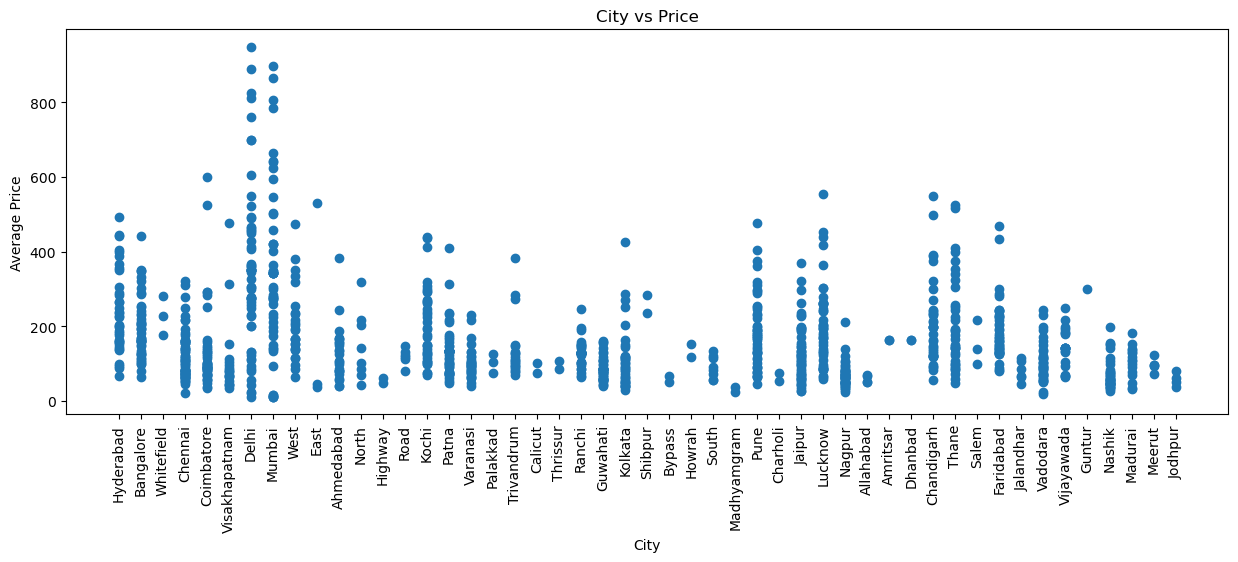

In [11]:
plt.figure(figsize=(15,5))
plt.scatter(buy["City"],buy["Average Price"])
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=90)
plt.title("City vs Price")
plt.show()

The scatter plot shows the distribution of property prices across different cities. Each point represents a property listing. Cities with points higher on the y-axis indicate higher priced properties, while cities with points clustered lower represent more affordable housing markets.

### Categorical X Numerical

### How does the price distribution look in the top 5 expensive cities?

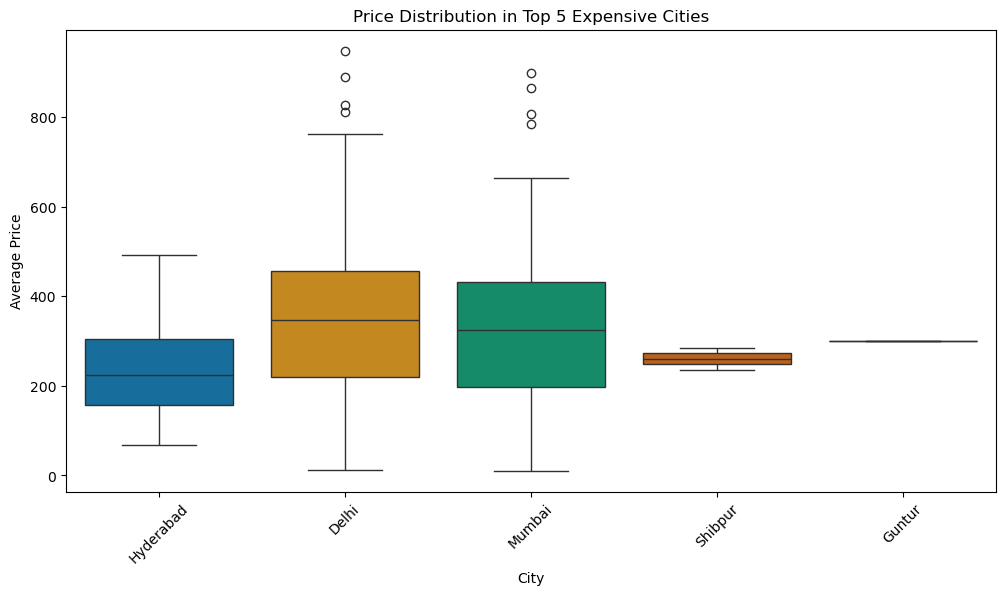

In [12]:
top5_list = buy.groupby("City")["Average Price"].mean().sort_values(ascending=False).head(5).index
top5_df = buy[buy["City"].isin(top5_list)]
plt.figure(figsize=(12,6))
sns.boxplot(x="City", y="Average Price", data=top5_df,palette="colorblind")
plt.xticks(rotation=45)
plt.title("Price Distribution in Top 5 Expensive Cities")
plt.show()

- Delhi and Mumbai show several high-value outliers (above 800–900 lakhs), indicating the presence of luxury properties, while Shibpur and Guntur have much smaller price variation.
- Hyderabad shows comparatively lower median prices (~210–220 lakhs) with a moderate spread,
- suggesting more balanced property pricing.

### top 5 best cities to buy property under 100k budget

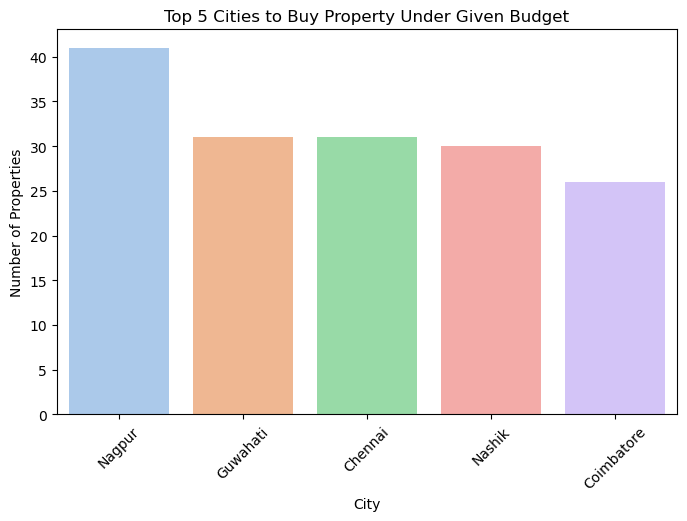

In [13]:
budget = 100
budget_df = buy[buy["Average Price"] <= budget]
top5_cities = budget_df["City"].value_counts().head(5)
plt.figure(figsize=(8,5))
sns.barplot(top5_cities,palette="pastel")
plt.title("Top 5 Cities to Buy Property Under Given Budget")
plt.xlabel("City")
plt.ylabel("Number of Properties")
plt.xticks(rotation=45)
plt.show()

### In Hyderabad, which top 5 areas have the best property options under ₹4 crore

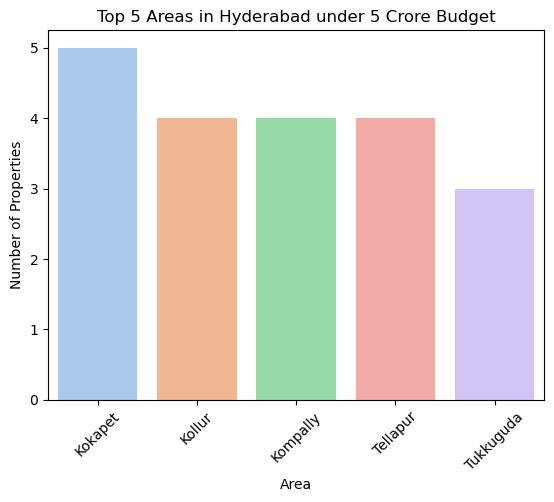

In [14]:
budget = 400  
hyd_df = buy[(buy["City"]=="Hyderabad") & (buy["Average Price"]<=budget)]
top5 = hyd_df["Area"].value_counts().head(5)
sns.barplot(top5,palette='pastel')
plt.title("Top 5 Areas in Hyderabad under 5 Crore Budget")
plt.xlabel("Area")
plt.ylabel("Number of Properties")
plt.xticks(rotation=45)
plt.show()

### Numerical X Numerical

### correlation between bhk and average price

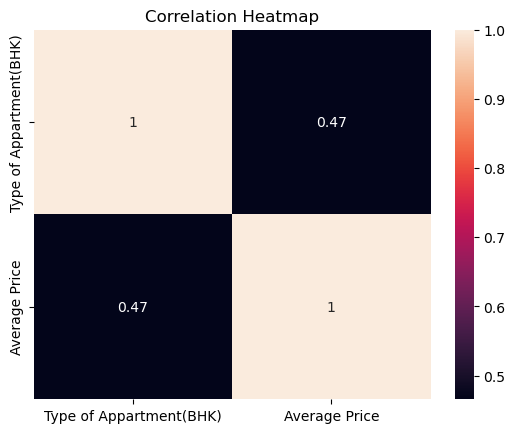

In [15]:
numeric_df = buy.select_dtypes(include=["int64","float64"])
sns.heatmap(numeric_df.corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

As we can see they both are positively corellated as bhk increases price also increases

### How does price vary with apartment type (BHK)?

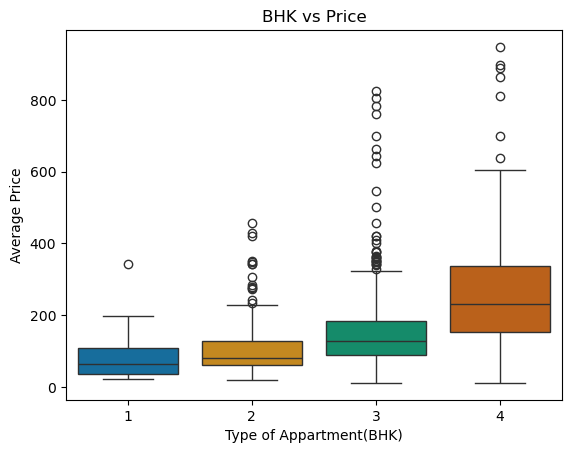

In [16]:
sns.boxplot(x="Type of Appartment(BHK)",y="Average Price",data=buy,palette="colorblind")
plt.title("BHK vs Price")
plt.show()

- Price variability increases for higher BHK types, especially for 3 BHK and 4 BHK, where prices range widely and include many high-value outliers above 600–900 lakhs, indicating luxury properties.
- 1 BHK properties show the smallest spread, meaning their prices are more consistent compared to larger apartments.

### Multivariate Analysis

### Builders and their property count in each city

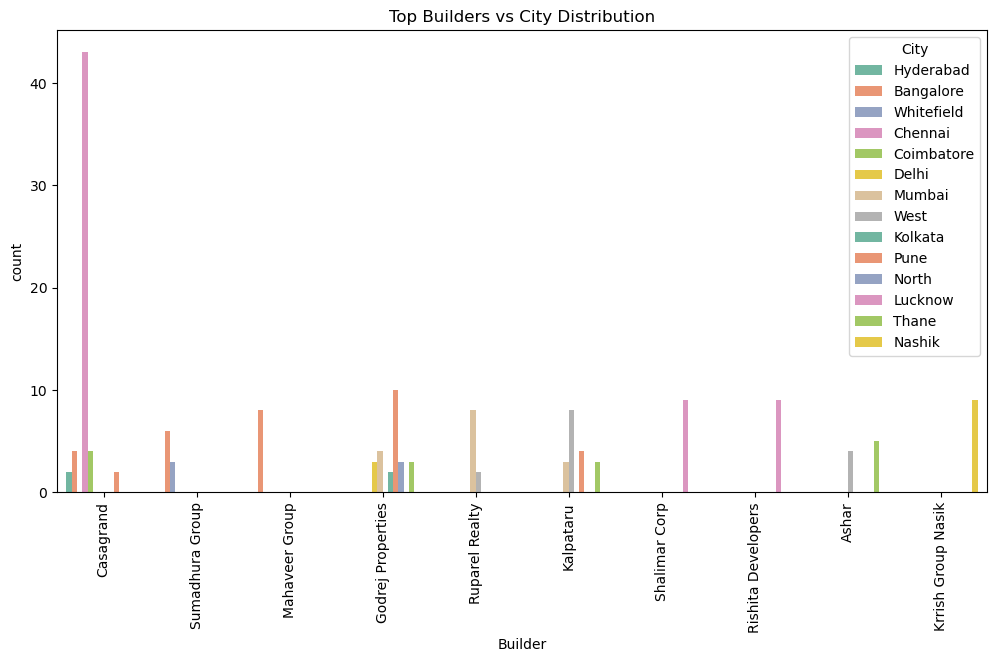

In [18]:
top_builders = buy["Builder"].value_counts().head(10).index
builder_df = buy[buy["Builder"].isin(top_builders)]
plt.figure(figsize=(12,6))
sns.countplot(x="Builder",hue="City",data=builder_df,palette="Set2")
plt.xticks(rotation=90)
plt.title("Top Builders vs City Distribution")
plt.show()

- Casagrand dominates the dataset with the highest number of listings (over 40) mainly concentrated in Chennai, indicating a strong presence of this builder in that city.
- Builders like Godrej Properties, Rishita Developers, and Shalimar Corp show moderate listings (around 8–10), suggesting they have significant but more distributed projects across cities.
- Several builders such as Kalpataru, Ruparel Realty, and Ashar appear only in a few cities with smaller counts, indicating a more localized market presence.

### Pivot Table 

In [17]:
pivot_table = pd.pivot_table(buy,values="Average Price",index="Type of Appartment(BHK)",columns="City",aggfunc="mean")
pivot_table

City,Ahmedabad,Allahabad,Amritsar,Bangalore,Bypass,Calicut,Chandigarh,Charholi,Chennai,Coimbatore,...,South,Thane,Thrissur,Trivandrum,Vadodara,Varanasi,Vijayawada,Visakhapatnam,West,Whitefield
Type of Appartment(BHK),,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,131.126596,NaN,NaN,NaN,NaN,20.440000,36.750000,...,91.010,87.696250,NaN,NaN,NaN,43.350000,NaN,NaN,98.2400,NaN
2,55.132500,51.705,NaN,115.100000,49.7,76.0,108.333333,52.30,81.478261,86.023545,...,56.785,147.457692,85.0,86.865,19.500000,79.440303,99.125714,53.845,153.9830,175.5
3,116.160667,69.270,164.554921,184.769565,67.2,102.5,158.408696,74.13,111.770973,124.672632,...,91.500,277.681818,106.0,131.850,75.130526,100.318810,139.431111,116.085,249.1875,226.5
4,223.100000,NaN,164.554921,277.964286,NaN,NaN,322.500000,NaN,188.852941,364.400000,...,124.500,448.500000,NaN,231.250,142.429412,179.500000,206.900000,477.000,341.2529,282.5


- The pivot table shows that property prices generally increase as BHK size increases, for example in Bangalore the average price rises from ~131 lakhs (1 BHK) to ~277 lakhs (4 BHK).
- Some cities have very high average prices for larger apartments, such as Coimbatore where 4 BHK averages around 364 lakhs and Thane around 448 lakhs, indicating premium housing markets.